### Import libraries: 

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
print("done!")

done!


### Import Data :


In [2]:
df = pd.read_csv("Clean_Dataset.csv")
df.shape

(300153, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [4]:
# Naming the unamed index column
df = df.rename(columns = {df.columns[0]: "id"})

In [5]:
# displaying as lists the unique elements of each column

airlines = df["airline"].unique().tolist()
flights = df["flight"].unique().tolist()
source_cities = df["source_city"].unique().tolist()
departure_times = df["departure_time"].unique().tolist()
stops = df["stops"].unique().tolist()
arrival_times = df["arrival_time"].unique().tolist()
destination_cities = df["destination_city"].unique().tolist()
classes = df["class"].unique().tolist()

print("Airlines:", airlines)
print("Number of unique flights:", len(flights))
print("Source Cities:", source_cities)
print("Departure Times:", departure_times)
print("Stops:", stops)
print("Arrival Times:", arrival_times)
print("Destination Cities:", destination_cities)
print("Classes:", classes)

Airlines: ['SpiceJet', 'AirAsia', 'Vistara', 'GO_FIRST', 'Indigo', 'Air_India']
Number of unique flights: 1561
Source Cities: ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']
Departure Times: ['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Stops: ['zero', 'one', 'two_or_more']
Arrival Times: ['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']
Destination Cities: ['Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai', 'Delhi']
Classes: ['Economy', 'Business']


In [6]:
# Mapping the stops column to numerical representative values
if df['stops'].dtype == 'object': 
    df['stops'] =df['stops'].map({'zero':0, 'one' : 1, 'two_or_more' :2})
    print("results : ",df['stops'].unique().tolist())
else :
    print("stops column already mapped :",df['stops'].unique().tolist())

results :  [0, 1, 2]


### Classify the discrete, continuous, and categorical variables

In [ ]:
discrete_variables = []
continuous_variables = []
categorical_variables = []


for var in df.columns :
    if df[var].dtype == 'object' :
        categorical_variables.append(var)

    elif df[var].dtype == 'int64' or (df[var].dtype == 'float64' and (df[var].dropna() % 1 == 0).all()) :
        if len(df[var].unique()) > 100 :
            continuous_variables.append(var)
        else :
            discrete_variables.append(var)
            
    elif (df[var].dtype == 'float64' and (df[var].dropna() % 1 != 0).any()):
        continuous_variables.append(var)
        
    else:
        print(var, "is unknown")

print("Discrete:", discrete_variables)
print("Continuous:", continuous_variables)
print("Categorical:", categorical_variables)

Discrete: ['stops', 'days_left']
Continuous: ['id', 'duration', 'price']
Categorical: ['airline', 'flight', 'source_city', 'departure_time', 'arrival_time', 'destination_city', 'class']


### ANOVA test: examine the relationship between airline (economy class) and price: 

In [8]:
# Filter to include only the economy class (the common class among all airlines)
df_economy = df[df["class"]== "Economy"]

#list of all unique airlines in the dataset with economy class
airlines = df_economy["airline"].unique().tolist()

dict_airline_prices = {}

# Iterate over each airline, extracting economy class prices
for airline in airlines :
    airline_prices = df_economy[df_economy['airline'] == airline]['price']
    dict_airline_prices[airline] = airline_prices

# Anova test
anova_results = sp.stats.f_oneway(*dict_airline_prices.values())
print(f"P-value:{anova_results[1]}")



P-value:0.0


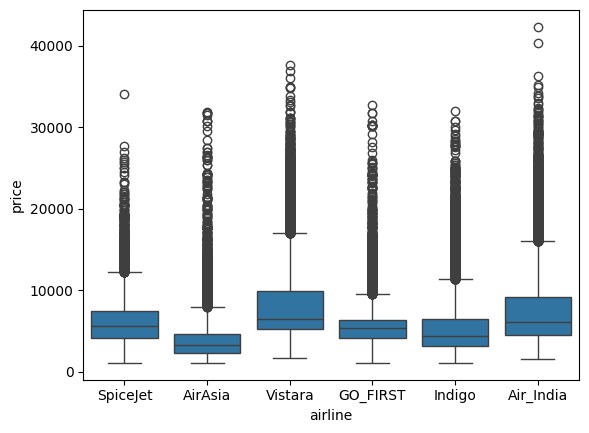

In [9]:
sns.boxplot( data = df_economy, x= "airline",y = "price")
plt.show()

### Pearson correlation test: examine the linear relationship between flight duration and price

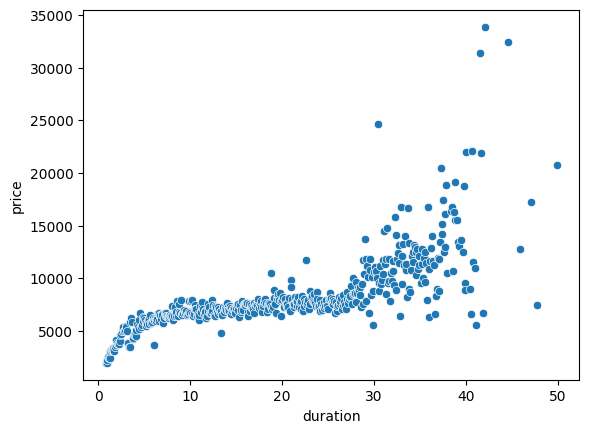

In [10]:
data = df_economy[["duration", "price"]].groupby("duration").mean()
sns.scatterplot( data = data, x= "duration",y = "price")
plt.show()

In [11]:
# We use Pearson because we consider price to be continuous (it has more than 12k unique values) 
# with a large dataset of 300k rows
len(df["price"].unique())

12157

In [12]:
results_pearson = sp.stats.pearsonr(df_economy["duration"], df_economy["price"])
print(f"p value : {results_pearson[1]}")
print(f"r : {results_pearson[0]}")

p value : 0.0
r : 0.2883790509590053


### ML Pipline

### Encoding ordinal and nominal columns :

In [13]:
df["departure_time"].unique().tolist()

['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']

In [14]:
df["arrival_time"].unique().tolist()

['Night', 'Morning', 'Early_Morning', 'Afternoon', 'Evening', 'Late_Night']

### Ordinal encoding using Mapping 

In [ ]:
time_mapping = {
    'Early_Morning': 1,
    'Morning': 2,
    'Afternoon': 3,
    'Evening': 4,
    'Night': 5,
    'Late_Night': 6
}
#mapping :
for col in ['arrival_time', 'departure_time' ]:
    if col in df.columns:
        if df[col].dtype == 'object': 
            df[col + '_mapped'] = df[col].map(time_mapping)
            print("results : ",df[col + '_mapped'].unique().tolist())
            df.drop(columns= col , inplace=True)
        else :
            print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")     
    else :
        print(f"{col} column already mapped : {df[col+'_mapped'].unique().tolist()}")

arrival_time column already mapped : [5, 2, 1, 3, 4, 6]
departure_time column already mapped : [4, 1, 2, 3, 5, 6]


### Nominal Encoding Using OneHotMapping 

In [19]:
from sklearn.preprocessing import OneHotEncoder

#columns = ['airline','flight', 'source_city', 'destination_city', "class"]
columns = df.select_dtypes( include ='object').columns.tolist()

for col in columns :
    if col in df.columns :
        if df[col].dtype == 'object':
            encoder = OneHotEncoder(sparse_output=False)
            encoded = encoder.fit_transform(df[[col]])
            df[encoder.get_feature_names_out([col])] = encoded 
            df.drop(columns=col, inplace = True)
        else :
            print("columns are already encoded")
    else :
        print("columns are already encoded and originals were droped")

 

C:\Users\rachid\AppData\Local\Temp\ipykernel_6580\2993399188.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[encoder.get_feature_names_out([col])] = encoded
C:\Users\rachid\AppData\Local\Temp\ipykernel_6580\2993399188.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[encoder.get_feature_names_out([col])] = encoded
C:\Users\rachid\AppData\Local\Temp\ipykernel_6580\2993399188.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor per

In [20]:
df

,id,stops,duration,days_left,price,arrival_time_mapped,departure_time_mapped,airline_AirAsia,airline_Air_India,airline_GO_FIRST,...,source_city_Kolkata,source_city_Mumbai,destination_city_Bangalore,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai,class_Business,class_Economy
0,0,0,2.17,1,5953,5,4,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1,0,2.33,1,5953,2,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,2,0,2.17,1,5956,1,1,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,3,0,2.25,1,5955,3,2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,4,0,2.33,1,5955,2,2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,1,10.08,49,69265,4,2,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300149,300149,1,10.42,49,77105,5,3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300150,300150,1,13.83,49,79099,5,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
300151,300151,1,10.00,49,81585,4,1,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [21]:
df.to_csv('Clean_Dataset_encoded.csv', index=False)


KeyboardInterrupt: 